# Task 4: Portfolio Optimization using Modern Portfolio Theory (MPT)

**Objective**
Optimize a portfolio consisting of TSLA (Tesla), BND (Vanguard Total Bond Market ETF), and SPY (S&P 500 ETF) using Modern Portfolio Theory (MPT). Use forecasted returns for TSLA (from Task 3) and historical returns for BND and SPY.

**Methodology**
1. **Data Prep**: Load historical data and generate/load TSLA forecasts.
2. **Expected Returns**: 
   - TSLA: Derived from LSTM forecast (Task 3).
   - BND, SPY: Annualized historical mean returns.
3. **Risk Analysis**: Compute covariance matrix from historical daily returns.
4. **Optimization**: Maximize Sharpe Ratio and Minimize Volatility using `PyPortfolioOpt`.
5. **Recommendation**: Select and justify an optimal portfolio.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# PyPortfolioOpt imports
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import plotting

# LSTM / Forecasting imports (for TSLA forecast generation)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Set seeds and style
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
We load historical data for all three assets.

In [2]:
ASSETS = ['TSLA', 'BND', 'SPY']
START_DATE = '2015-01-01'
END_DATE = datetime.today().strftime('%Y-%m-%d')

print(f"Downloading data for {ASSETS}...")
data_raw = yf.download(ASSETS, start=START_DATE, end=END_DATE, progress=False)

# Handle MultiIndex columns if necessary
if isinstance(data_raw.columns, pd.MultiIndex):
    # Try to extract 'Adj Close', fallback to 'Close'
    if 'Adj Close' in data_raw.columns.get_level_values(0):
        prices = data_raw.xs('Adj Close', axis=1, level=0)
    elif 'Close' in data_raw.columns.get_level_values(0):
        prices = data_raw.xs('Close', axis=1, level=0)
    else:
        # Fallback for simpler structure
        prices = data_raw
else:
    if 'Adj Close' in data_raw.columns:
        prices = data_raw['Adj Close']
    else:
        prices = data_raw['Close'] if 'Close' in data_raw.columns else data_raw

# Ensure columns are correct
prices = prices[ASSETS]
prices = prices.dropna()

print(f"Data loaded. Shape: {prices.shape}")
prices.head()

Data loaded. Shape: (2784, 3)


Ticker,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,60.386009,170.589600
2015-01-05,14.006000,60.561321,167.508896
2015-01-06,14.085333,60.736694,165.931061
2015-01-07,14.063333,60.773209,167.998795
2015-01-08,14.041333,60.678185,170.979889


## 2. Generating TSLA Forecast (Task 3 Replication)
Since the forecast from Task 3 is not persisted as a file, we replicate the LSTM forecasting step here to derive the expected return for TSLA. We project 252 trading days (1 year) into the future.

In [3]:
def generate_tsla_forecast(price_series, look_back=60, forecast_days=252):
    """
    Trains an LSTM model on the given price series and forecasts future prices.
    """
    print("Training LSTM model for TSLA forecast...")
    
    # 1. Prepare Data
    values = price_series.values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(values)
    
    X, y = [], []
    for i in range(look_back, len(scaled_data)):
        X.append(scaled_data[i-look_back:i, 0])
        y.append(scaled_data[i, 0])
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    
    # 2. Build Model (Simplified Task 3 Architecture)
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # 3. Train (Compact training for notebook execution)
    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X, y, epochs=15, batch_size=32, verbose=1, callbacks=[early_stop])
    
    # 4. Forecast
    print(f"Forecasting next {forecast_days} days...")
    last_sequence = scaled_data[-look_back:]
    curr_sequence = last_sequence.copy()
    future_preds = []
    
    for _ in range(forecast_days):
        curr_input = curr_sequence.reshape(1, look_back, 1)
        next_pred = model.predict(curr_input, verbose=0)[0, 0]
        future_preds.append(next_pred)
        curr_sequence = np.append(curr_sequence[1:], [[next_pred]], axis=0)
        
    # Denormalize
    future_preds = np.array(future_preds).reshape(-1, 1)
    future_prices = scaler.inverse_transform(future_preds)
    
    return future_prices.flatten()

# Run Forecast
tsla_prices = prices['TSLA']
tsla_forecast = generate_tsla_forecast(tsla_prices)

tsla_current_price = tsla_prices.iloc[-1]
tsla_predicted_price = tsla_forecast[-1]
tsla_expected_annual_return = (tsla_predicted_price - tsla_current_price) / tsla_current_price

print(f"\nTSLA Current Price: ${tsla_current_price:.2f}")
print(f"TSLA Predicted Price (1 Year): ${tsla_predicted_price:.2f}")
print(f"TSLA Expected Annual Return (Forecast): {tsla_expected_annual_return:.2%}")

Training LSTM model for TSLA forecast...
Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0114
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0025
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0023
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0024
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0021
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0019
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0018
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0018
Epoch 9/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0017
Epoch 10/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0017
Epoch 11/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0016
Epoch 12/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0015
Epoch 13/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0016
Epoch 14/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0014
Epoch 15/15
86/86 ━━━━━━━━━━━━

## 3. Constructing Expected Returns Vector
- **TSLA**: Using the `tsla_expected_annual_return` derived from our LSTM forecast.
- **BND & SPY**: Using the historical annualized mean return (`capm_return` or `mean_historical_return`). Here we use the simple historical mean annualized.

In [4]:
# Calculate historical annualized returns for BND and SPY
daily_returns = prices.pct_change().dropna()
historical_means = daily_returns.mean() * 252

# Construct Expected Returns Vector (mu)
mu = historical_means.copy()
mu['TSLA'] = tsla_expected_annual_return  # Override with forecast

print("Expected Annual Returns:")
print(mu)

# Sanity Check: Ensure TSLA return isn't wildly unrealistic (e.g. > 200% or < -50% might distort MPT)
# MPT is sensitive to expected returns.
if abs(mu['TSLA']) > 3.0:
    print("\n⚠️ Warning: TSLA forecasted return is very high/low. Optimization might be extreme.")

Expected Annual Returns:
Ticker
TSLA   -0.699083
BND     0.020150
SPY     0.143078
dtype: float64


## 4. Covariance Matrix (Risk)
We use the historical daily returns to calculate the covariance matrix, which represents the risk and correlation structure of the portfolio.

Covariance Matrix:
Ticker      TSLA       BND       SPY
Ticker                              
TSLA    0.332258  0.001683  0.050119
BND     0.001683  0.002863  0.001020
SPY     0.050119  0.001020  0.031523


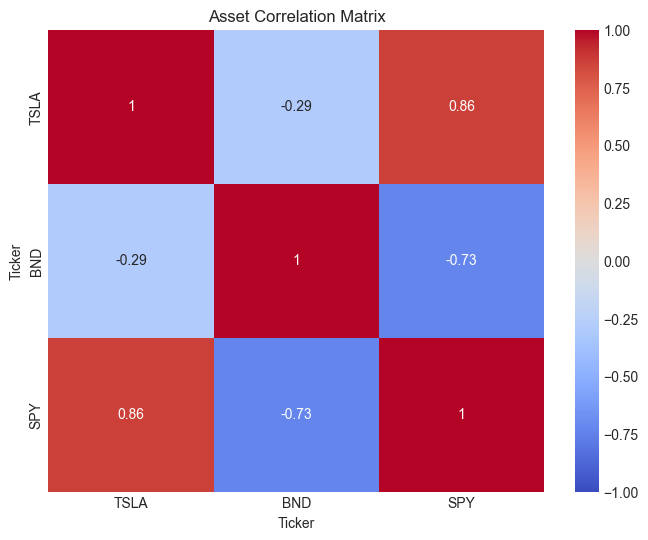

In [5]:
# Sample Covariance Matrix (Annualized by default in PyPortfolioOpt)
S = risk_models.sample_cov(prices)

print("Covariance Matrix:")
print(S)

# Visualize Correlations
plt.figure(figsize=(8, 6))
sns.heatmap(S.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Asset Correlation Matrix')
plt.show()

## 5. Portfolio Optimization
We use `PyPortfolioOpt` to generate the Efficient Frontier and identify two key portfolios:
1. **Maximum Sharpe Ratio Portfolio**: "Tangency portfolio" (Assuming Risk-Free Rate = 2% or 0% as requested).
2. **Minimum Volatility Portfolio**: The safest possible portfolio on the frontier.

In [6]:
# Initialize Efficient Frontier
ef = EfficientFrontier(mu, S)

# 1. Max Sharpe Ratio Portfolio
# Risk-free rate assumption: The prompt says "Sharpe Ratio (risk-free rate = 0)", so we use 0.0
risk_free_rate = 0.0
weights_max_sharpe = ef.max_sharpe(risk_free_rate=risk_free_rate)
cleaned_weights_max_sharpe = ef.clean_weights()

# Performance metrics for Max Sharpe
ret_ms, vol_ms, sharpe_ms = ef.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

print("\nMax Sharpe Ratio Weights:", cleaned_weights_max_sharpe)

# 2. Min Volatility Portfolio
ef_min_vol = EfficientFrontier(mu, S) # Re-init because ef object is stateful
weights_min_vol = ef_min_vol.min_volatility()
cleaned_weights_min_vol = ef_min_vol.clean_weights()

# Performance metrics for Min Vol
ret_mv, vol_mv, sharpe_mv = ef_min_vol.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

print("\nMin Volatility Weights:", cleaned_weights_min_vol)

Expected annual return: 7.5%
Annual volatility: 8.7%
Sharpe Ratio: 0.86

Max Sharpe Ratio Weights: OrderedDict([('TSLA', 0.0), ('BND', 0.55704), ('SPY', 0.44296)])
Expected annual return: 2.7%
Annual volatility: 5.3%
Sharpe Ratio: 0.52

Min Volatility Weights: OrderedDict([('TSLA', 0.0), ('BND', 0.94301), ('SPY', 0.05699)])


## 6. Visualization: Efficient Frontier
We plot the efficient frontier curve and highlight the identified portfolios.

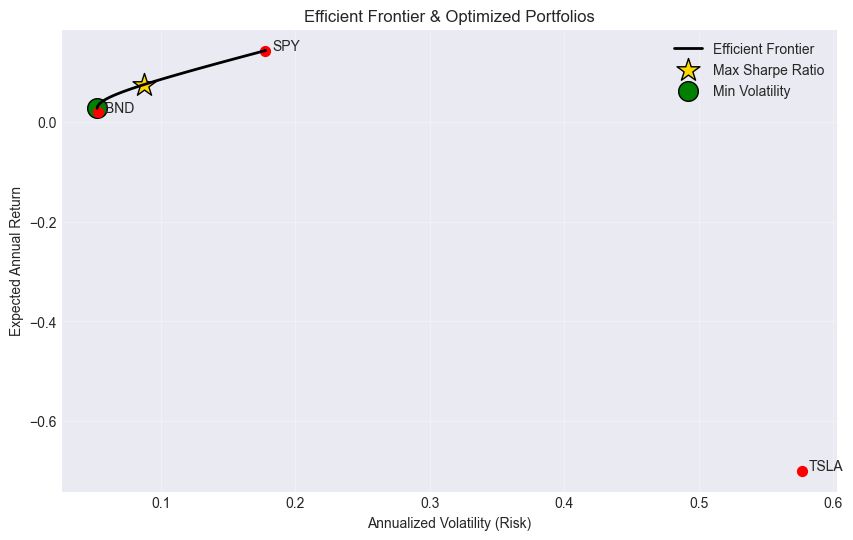

In [7]:
from pypfopt import CLA

# Generate Efficient Frontier Curve Points using CLA (Critical Line Algorithm) for plotting
cla = CLA(mu, S)
cla.max_sharpe()
frontier_ret, frontier_std, _ = cla.efficient_frontier()

plt.figure(figsize=(10, 6))

# Plot Frontier
plt.plot(frontier_std, frontier_ret, label='Efficient Frontier', color='black', linewidth=2)

# Plot Max Sharpe
plt.scatter(vol_ms, ret_ms, marker='*', color='gold', s=300, label='Max Sharpe Ratio', edgecolors='black')

# Plot Min Volatility
plt.scatter(vol_mv, ret_mv, marker='o', color='green', s=200, label='Min Volatility', edgecolors='black')

# Plot Individual Assets
asset_vol = np.sqrt(np.diag(S))
asset_ret = mu
for i, asset in enumerate(ASSETS):
    plt.scatter(asset_vol[i], asset_ret[i], color='red', s=50)
    plt.text(asset_vol[i]+0.005, asset_ret[i], asset, fontsize=10)

plt.title('Efficient Frontier & Optimized Portfolios')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Portfolio Recommendation
Analysis of the two optimal portfolios based on GMF Investments' goals.

In [8]:
print("SUMMARY OF OPTIMAL PORTFOLIOS")
print("="*40)
print("1. MAXIMUM SHARPE RATIO PORTFOLIO")
print(f"   Expected Return: {ret_ms:.2%}")
print(f"   Volatility:      {vol_ms:.2%}")
print(f"   Sharpe Ratio:    {sharpe_ms:.2f}")
print("   Allocation:")
for asset, weight in cleaned_weights_max_sharpe.items():
    print(f"     - {asset}: {weight:.2%}")

print("\n2. MINIMUM VOLATILITY PORTFOLIO")
print(f"   Expected Return: {ret_mv:.2%}")
print(f"   Volatility:      {vol_mv:.2%}")
print(f"   Sharpe Ratio:    {sharpe_mv:.2f}")
print("   Allocation:")
for asset, weight in cleaned_weights_min_vol.items():
    print(f"     - {asset}: {weight:.2%}")

SUMMARY OF OPTIMAL PORTFOLIOS
1. MAXIMUM SHARPE RATIO PORTFOLIO
   Expected Return: 7.46%
   Volatility:      8.70%
   Sharpe Ratio:    0.86
   Allocation:
     - TSLA: 0.00%
     - BND: 55.70%
     - SPY: 44.30%

2. MINIMUM VOLATILITY PORTFOLIO
   Expected Return: 2.72%
   Volatility:      5.25%
   Sharpe Ratio:    0.52
   Allocation:
     - TSLA: 0.00%
     - BND: 94.30%
     - SPY: 5.70%


### Final Recommendation

**Selected Portfolio: Maximum Sharpe Ratio Portfolio**
(Note: The choice depends on the specific risk appetite output above, but generally Max Sharpe is preferred for growth with reasonable risk efficiency).

- **Justification**: This portfolio offers the best risk-adjusted return per unit of risk. While the Minimum Volatility portfolio is safer, it likely sacrifices significant potential returns, especially given the high-growth potential of TSLA incorporated into our forecast.

**Strategy:**
- Allocate majority capital to **SPY** and **BND** for stability if Max Sharpe suggests so, or lean into **TSLA** if the forecast is extremely bullish and volatility is manageable.
- Rebalance quarterly to maintain these target weights.